In [ ]:
import numpy as np
import pandas as pd
import pickle
from cidp_methods import correct_target, remove_unwanted_fields, img_paths_to_idp_df_eid_in_fname
from atlas_methods import create_atlas_target, add_lat_target
import nibabel as nib
from nilearn.image import load_img
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from nilearn.plotting import plot_stat_map, show
import scipy.stats as stats

In [6]:

# field ids and n_pcs used for our experiments
used_idps = {
   "Mean intensity of Pallidum (right hemisphere)": "26576_76",
  "Mean intensity of Putamen (left hemisphere)": "26544_21",
  "Volume of Hippocampus (left hemisphere)": "26562_46",
  "Volume of Caudate (left hemisphere)": "26559_26",
  "Mean thickness of G-postcentral (right hemisphere)": "27652_101",
  "Mean thickness of G-insular-short (left hemisphere)": "27420_326",
  "Area of G-rectus (left hemisphere)": "27359_426",
  "Area of G-orbital (left hemisphere)": "27352_146",
  "Volume of Lateral-Ventricle (left hemisphere)": "26554_56",
  "Volume of Brain-Stem (whole brain)": "26526_16",
  
}


Mean intensity of Pallidum (right hemisphere)


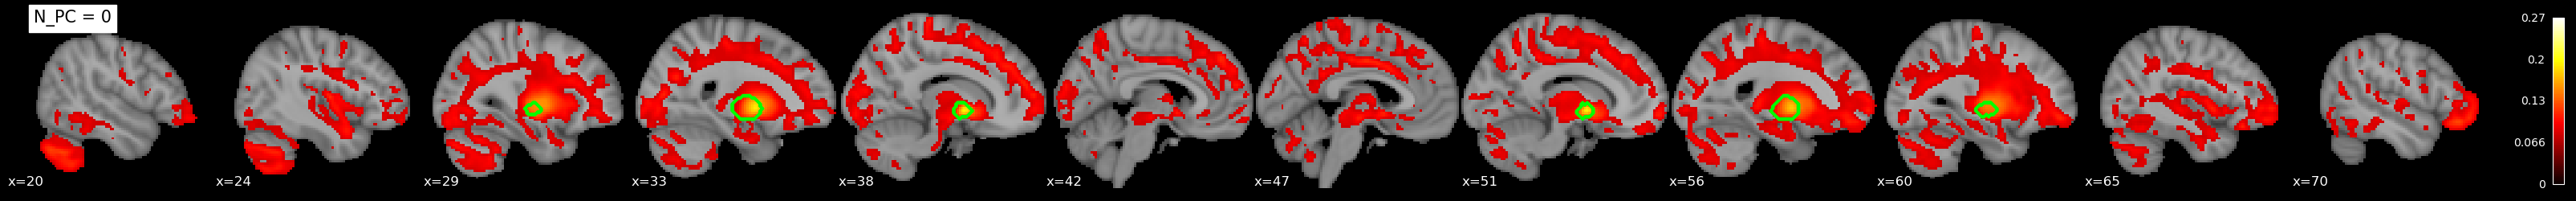

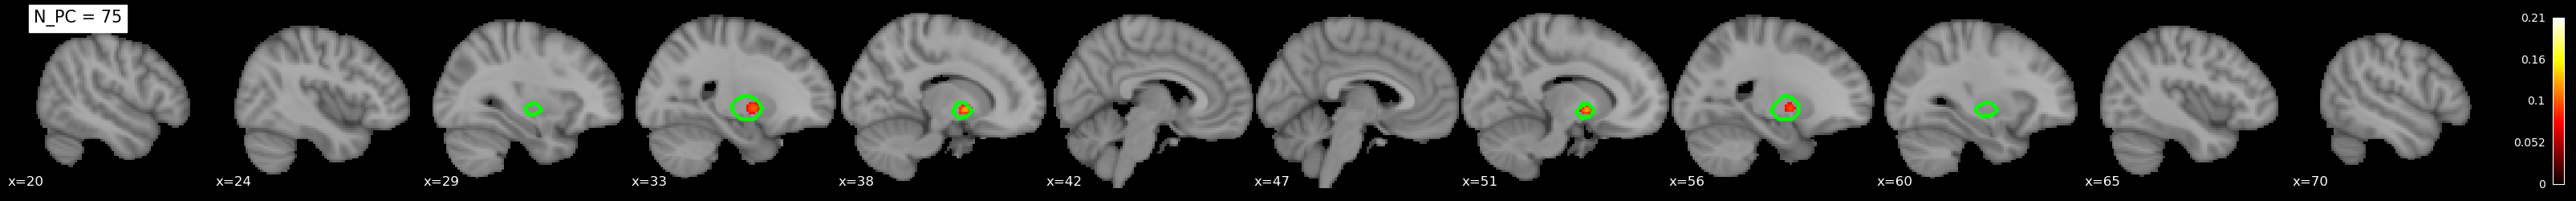

Mean intensity of Putamen (left hemisphere)


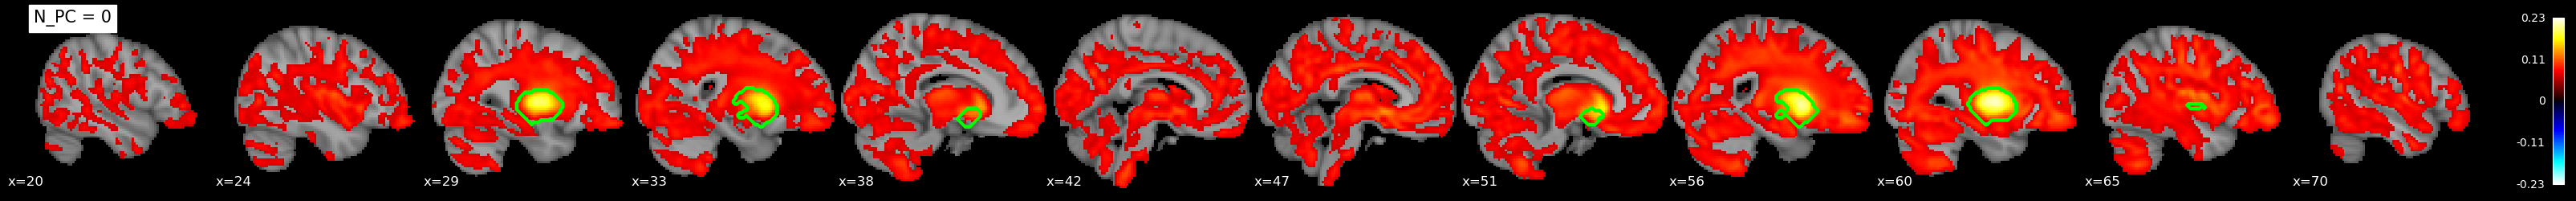

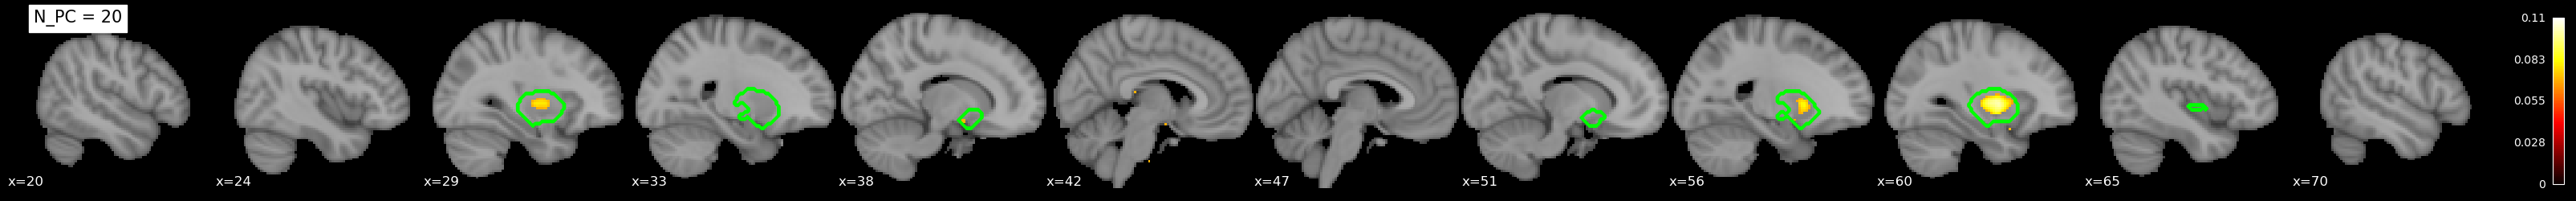

Volume of Hippocampus (left hemisphere)


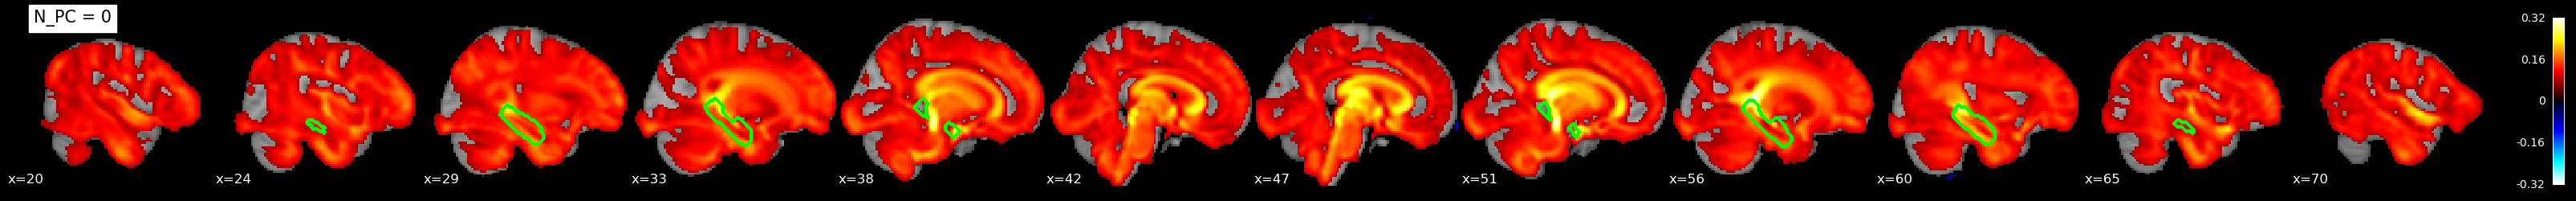

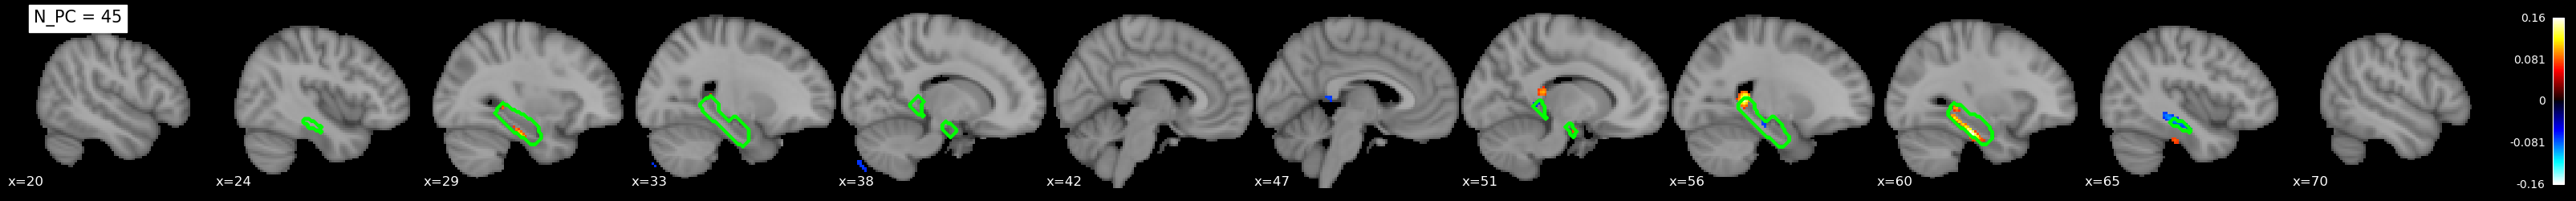

Volume of Caudate (left hemisphere)


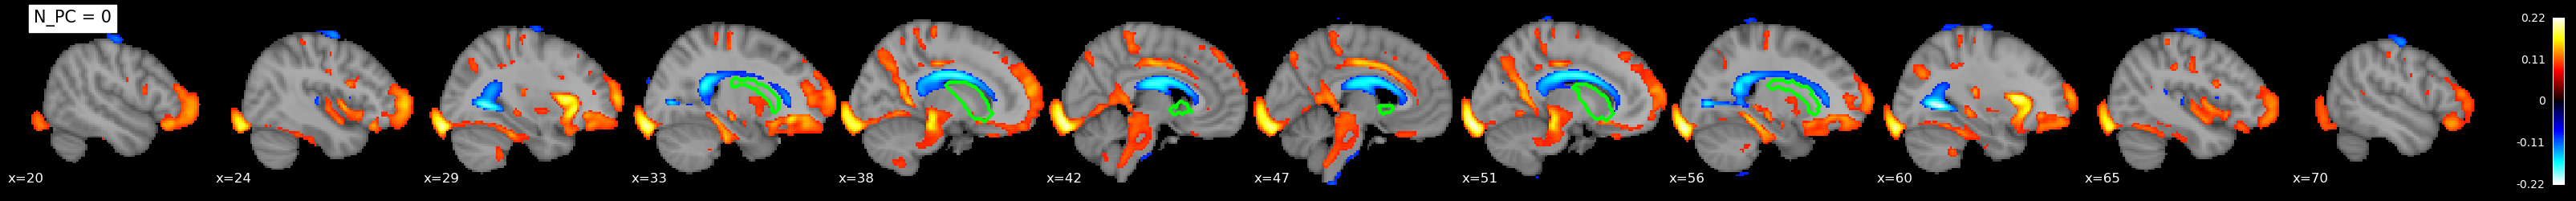

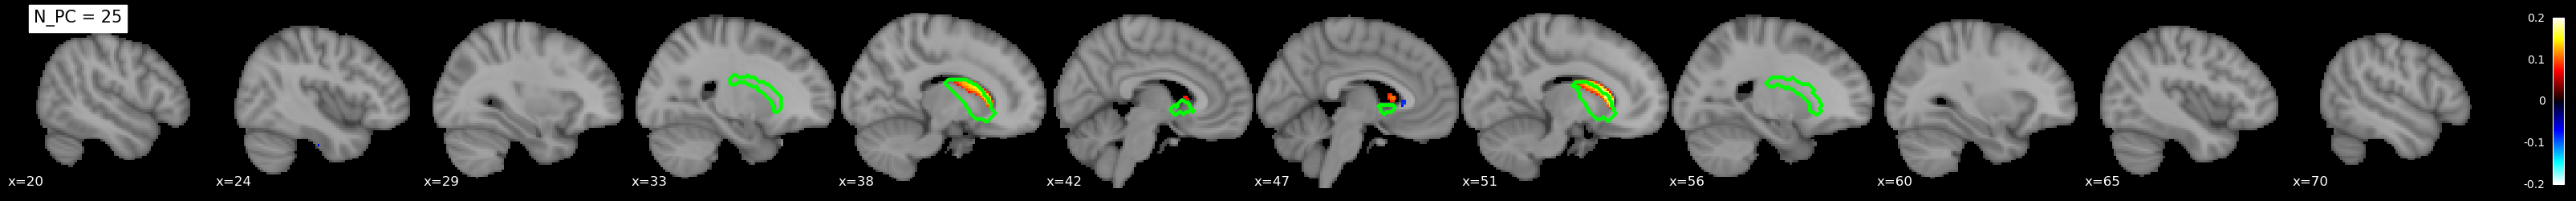

Mean thickness of G-postcentral (right hemisphere)


AttributeError: 'NoneType' object has no attribute 'get_fdata'

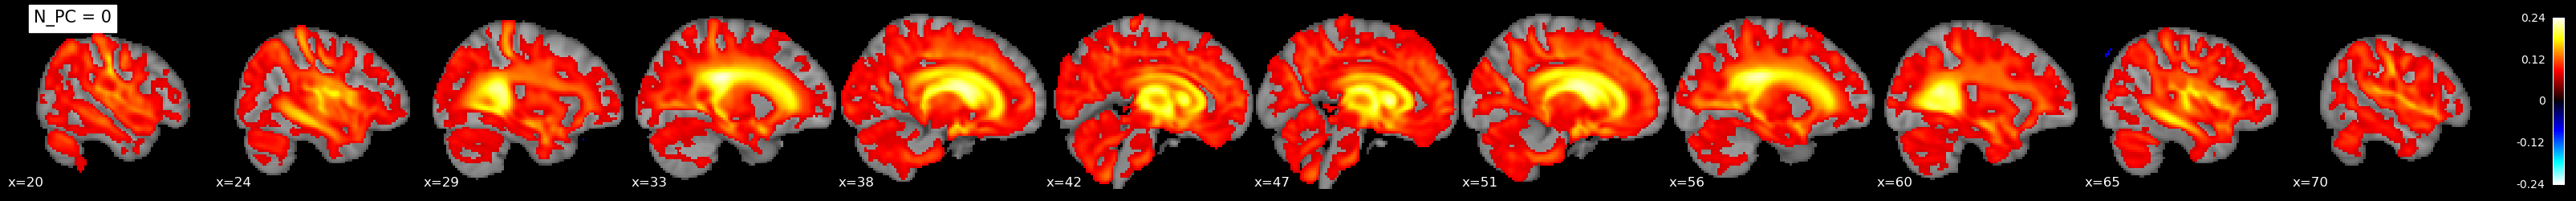

In [7]:
# include boundary voxels in visualization
dilation_iter = 2

# how many images to use for the analysis
n_imgs = 5000

# universal 10k masker w smoothing
masker_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/brain-xai-benchmark/files/brain_masker/10k_brain_masker.pkl"

# .nii images are stored in the following directory
path_to_images = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/lin_reg_imgs/int_downsampling/"

# bg image for visualization
img_bg_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/files/MNI/MNI152_T1_2mm_brain.nii.gz"

# iterate over all idps
for idp in used_idps:
    print(idp)

    idp_id = used_idps[idp]
    field = int(used_idps[idp].split("_")[0])
    npc_optimal = int(used_idps[idp].split("_")[1])

    for npc in [1, npc_optimal]:
        
        # -1 due to bias
        actual_npc = npc - 1

        if field > 27000:
            # idp df created in prep/prep_mass_decorrelate.py
            idp_save_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/brain-xai-benchmark/idp_correction/setup_files/idp_dfs/idp_df_cortical.pkl"
            # previously masked images as 2D array:
            masked_imgs_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/brain-xai-benchmark/files/lin_reg_imgs/masked_array/masked_imgs_aparc2009.npy"
            # config csv relating atlas keys, ukbb field ids, and field names
            array_csv_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/brain-xai-benchmark/idp_correction/setup_files/config_csvs/config_cortical.csv"
            # which atlas to use for (debug) visualization
            which_atlas = "aparc2009"
            # prev computed p-values:
            result_dir = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/results/target_generation/aparc_int_downsample_200perm_5kimgs"

        else:
            idp_save_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/brain-xai-benchmark/idp_correction/setup_files/idp_dfs/idp_df_subcortical.pkl"
            masked_imgs_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/brain-xai-benchmark/files/lin_reg_imgs/masked_array/masked_imgs_aseg.npy"
            array_csv_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/brain-xai-benchmark/idp_correction/setup_files/config_csvs/config_subcortical.csv"
            which_atlas = "aseg"
            result_dir = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/results/target_generation/aseg_int_downsample_200perm_5kimgs"
            


        # load config csv
        config_df = pd.read_csv(array_csv_path, names=['idx', 'field', 'atlas_key', 'name'])

        # load masked images
        imgs_transformed = np.load(masked_imgs_path)

        # load masker
        with open(masker_path, 'rb') as file:
            nifti_masker = pickle.load(file)

        # load pvals
        neg_log_pval_path =f"{result_dir}/f.{field}.2.0/p_vals_{npc}.npy"
        neg_log_pvals = np.load(neg_log_pval_path)

        # load corrected targets
        corrected_targets_path = f"{result_dir}/f.{field}.2.0/decorr_target_{npc}.npy"
        corrected_targets = np.load(corrected_targets_path)

        # get indices for targets with images available
        idp_df = pd.read_pickle(idp_save_path)
        idp_df = idp_df.dropna()
        idp_df = img_paths_to_idp_df_eid_in_fname(path_to_images, idp_df, n_imgs)
        img_indices = list(idp_df[idp_df["reg_img_path"].notnull()].index)
        corrected_target_vis = corrected_targets[img_indices].ravel()

        # effect size maps
        correlations = np.array([stats.pearsonr(imgs_transformed[:, i], corrected_target_vis)[0] for i in range(imgs_transformed.shape[1])])
        corr_img = nifti_masker.inverse_transform(np.float32(correlations))

        # mask effect sizes by significance
        corr_img_data = corr_img.get_fdata()
        corr_img_data[(neg_log_pvals.squeeze() < 1.3) & (neg_log_pvals.squeeze() > -1.3)] = 0
        masked_corr_img = nib.Nifti1Image(np.float32(corr_img_data), np.eye(4))

        # load bg image
        bg_img = load_img(img_bg_path)
        bg_img = nib.Nifti1Image(bg_img.get_fdata(), np.eye(4))

        # plot effect size map
        cut_coords = np.linspace(20, 70, num=12, dtype="int16")
        display = plot_stat_map(
            masked_corr_img,
            bg_img=bg_img,
            display_mode="x",
            cut_coords=cut_coords,
            threshold=0.0,
            title = f"N_PC = {actual_npc}")


        # get atlas for visualization of ground truth
        atlas_key = int(config_df[config_df["field"] == field]["atlas_key"].iloc[0])
        atlas = create_atlas_target(atlas_key, which_atlas, dilation_iter=dilation_iter)
        atlas_target = add_lat_target(config_df, field, which_atlas, atlas, dilation_iter=dilation_iter)

        # plot ground truth
        display.add_contours(nib.Nifti1Image(np.float32(atlas_target), np.eye(4)), colors="lime")

        show()